# Part I - Exploratory Data Analysis of the Ford GoBike Dataset
### by Junnuthula Yashaswini Reddy


## Introduction

The Titanic dataset contains information about passengers who traveled on the RMS Titanic. It includes demographic information, ticket details, passenger class, fare, age, and survival status.

The goal of this exploratory data analysis is to investigate the characteristics of passengers, identify factors related to survival, and explore relationships among different variables using univariate, bivariate, and multivariate visualizations.

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [2]:

# Load dataset

df = pd.read_csv("dataset.csv")

# Display first five rows

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [4]:
# Dataset shape

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 891
Columns : 15


In [5]:
# Check missing values

df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
# Remove unnecessary columns

df = df.drop(columns=["deck", "embark_town", "alive"], errors="ignore")

# Fill missing values

df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Verify missing values

df.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alone         0
dtype: int64

# Univariate Exploration


In this section, we examine the distribution of individual variables in the dataset.

## Question 1


How is passenger age distributed?

In [7]:
# Function for histogram

def plot_histogram(column, bins, title, xlabel):
    plt.figure(figsize=(8,5))
    sns.histplot(df[column], bins=bins, color="steelblue")

    plt.axvline(df[column].mean(),
                color="red",
                linestyle="--",
                label="Mean")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

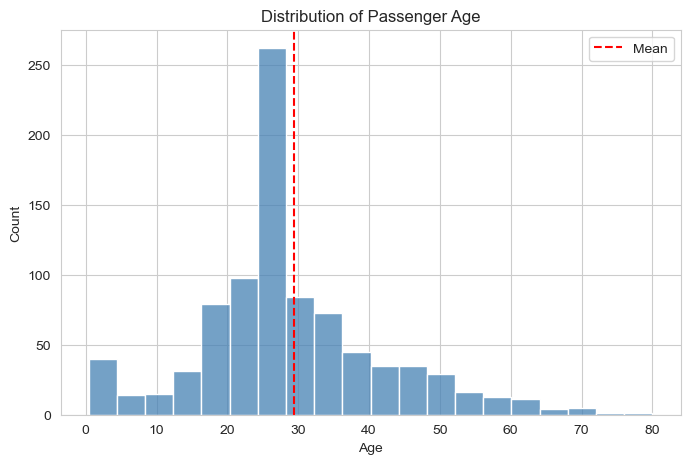

In [8]:
plot_histogram(
    "age",
    20,
    "Distribution of Passenger Age",
    "Age"
)


# Observation
The age distribution is right-skewed. Most passengers were between 20 and 40 years old. There are relatively fewer children and elderly passengers. The red dashed line represents the average passenger age.

## Question 2
How many passengers belonged to each passenger class?

In [9]:
# Function for count plot

def plot_count(column, title):

    plt.figure(figsize=(7, 5))

    ax = sns.countplot(
        data=df,
        x=column,
        hue=column,
        palette="Set2",
        legend=False
    )

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(title)
    plt.xlabel(column.capitalize())
    plt.ylabel("Number of Passengers")

    plt.show()

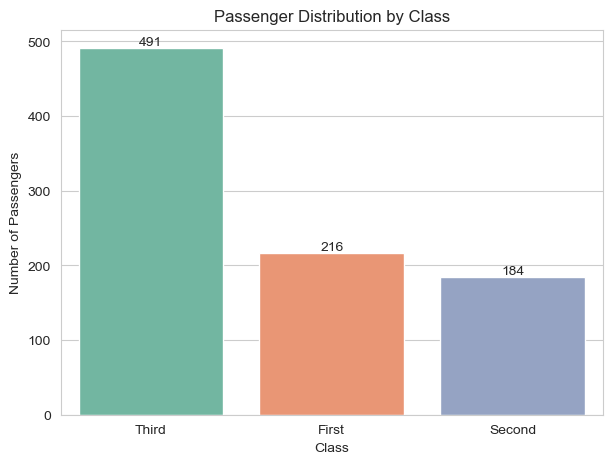

In [10]:
plot_count(
    "class",
    "Passenger Distribution by Class"
)

# Observation
Most passengers traveled in Third Class, followed by First Class and Second Class. Third Class contains the largest number of passengers in the dataset.

## Bivariate Exploration
In this section, we explore the relationship between two variables.

### Question 3
Is there any relationship between passenger age and fare paid?

In [11]:
# Function for scatter plot

def plot_scatter(x, y, title, xlabel, ylabel):

    plt.figure(figsize=(8,5))

    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        alpha=0.6
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.show()

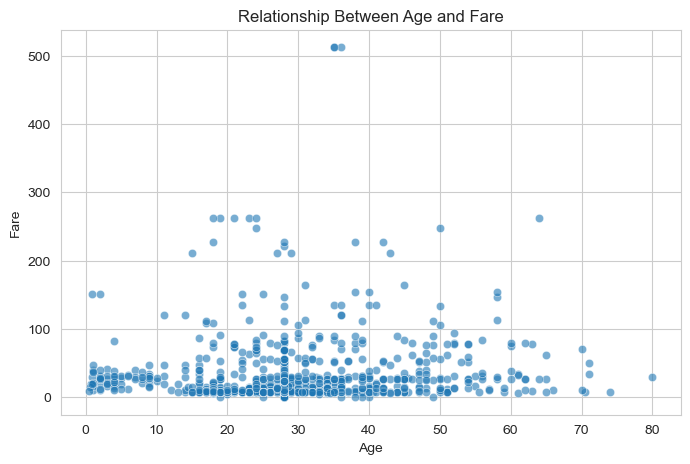

In [12]:
plot_scatter(
    "age",
    "fare",
    "Relationship Between Age and Fare",
    "Age",
    "Fare"
)


# Observation
Most passengers paid lower fares regardless of age. A few passengers paid very high fares, creating several outliers. There is no strong linear relationship between age and fare.

## Question 4
How does passenger age vary across different passenger classes?

In [13]:
def plot_box(x, y, title):

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x=x,
        y=y,
        hue=x,
        palette="Set2",
        legend=False
    )

    plt.title(title)
    plt.xlabel("Passenger Class")
    plt.ylabel("Age")

    plt.show()

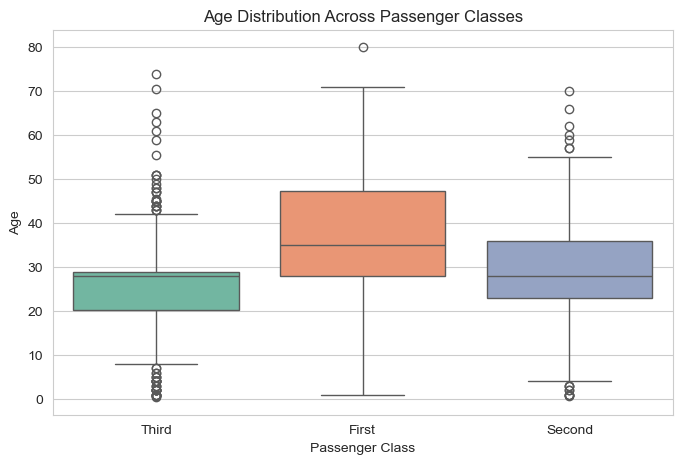

In [14]:
plot_box(
    "class",
    "age",
    "Age Distribution Across Passenger Classes"
)

# Observation
First Class passengers generally had a higher median age than Third Class passengers. Third Class also shows greater variability in passenger age.

## Question 5
Which numerical variables are strongly correlated?

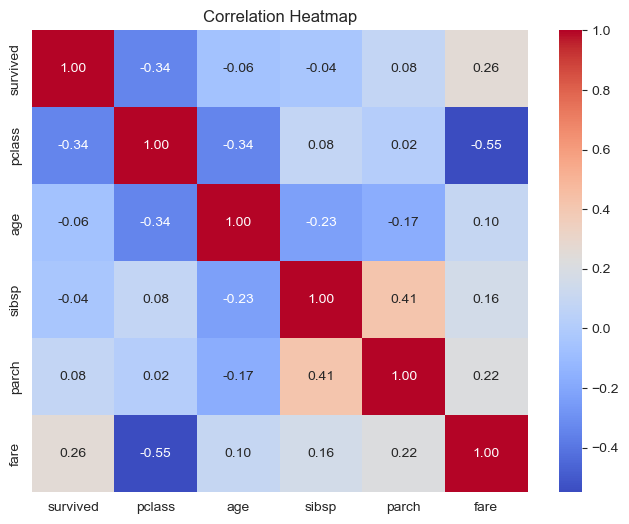

In [15]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Observation
The heatmap shows that fare is positively correlated with passenger class and survival, while age has only a weak correlation with most numerical variables.

## Multivariate Exploration
In this section, we examine relationships among three or more variables.

### Question 6
How does passenger age distribution vary across passenger classes based on survival status?

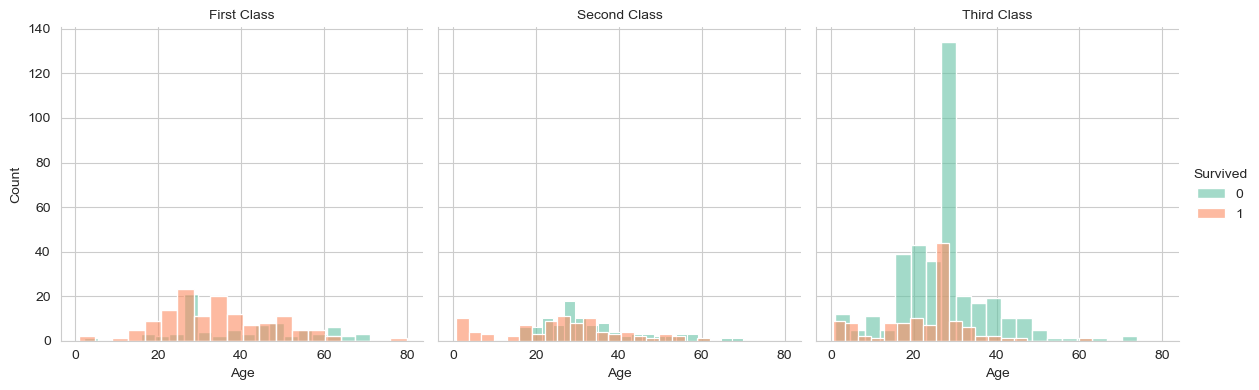

In [16]:
class_order = ["First", "Second", "Third"]

g = sns.FacetGrid(
    df,
    col="class",
    col_order=class_order,
    hue="survived",
    height=4,
    aspect=1,
    palette="Set2"
)

g.map(
    sns.histplot,
    "age",
    bins=20,
    alpha=0.6
)

g.set_titles("{col_name} Class")
g.set_axis_labels("Age", "Count")
g.add_legend(title="Survived")

plt.show()

# Observation
The FacetGrid reveals that First Class passengers had a higher survival rate across most age groups. Third Class passengers experienced lower survival rates, particularly among adults. This visualization simultaneously explores age, passenger class, and survival status.

## Question 7
How are fare, age, passenger class, and survival related?

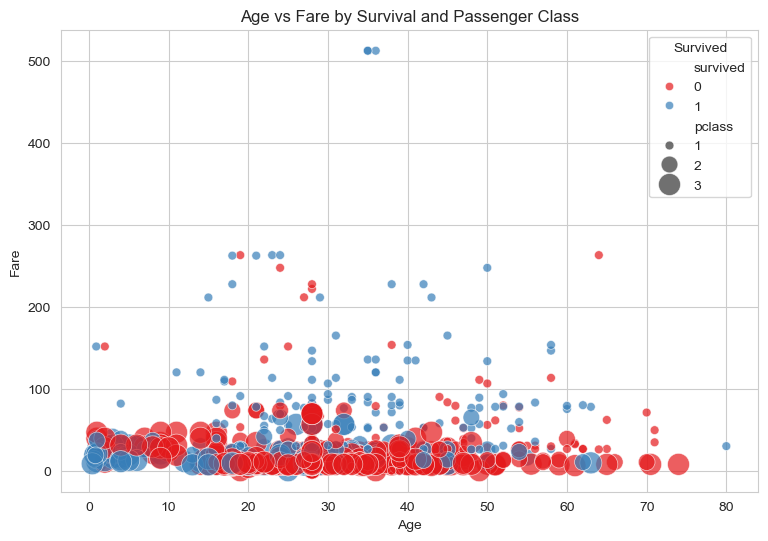

In [18]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    size="pclass",
    sizes=(40,250),
    alpha=0.7,
    palette="Set1"
)

plt.title("Age vs Fare by Survival and Passenger Class")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.legend(title="Survived")

plt.show()

# Observation
Passengers who paid higher fares were generally First Class travelers and had a greater chance of survival. Lower-fare passengers were mostly from Third Class and showed lower survival rates. This plot combines four variables to reveal multiple relationships simultaneously.

## Conclusions
This exploratory analysis identified several important patterns within the Titanic dataset.

Most passengers were between 20 and 40 years of age.
Third Class contained the highest number of passengers.
Passenger age showed little relationship with fare.
First Class passengers generally paid higher fares and had higher survival rates.
Survival was strongly associated with passenger class.
Multivariate visualizations confirmed that passengers traveling in First Class had a better probability of survival across different age groups.
These findings provide a strong foundation for selecting the most important visualizations for the explanatory presentation in Part II.